In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline

import math

from subprocess import check_output
print(check_output('dir .\\input', shell=True).decode('utf-8'))

 Volume in drive C has no label.
 Volume Serial Number is 2602-0473

 Directory of c:\Users\USER\Desktop\AI_study\kaggle_transcription\Natural language processing - classification, regression\2nd level. Mercari Price Suggestion Challenge\input

2026-09-19  오전 10:36    <DIR>          .
2026-09-19  오후 04:23    <DIR>          ..
2017-11-14  오전 09:43         9,595,930 sample_submission.csv
2026-03-07  오후 09:00           174,228 sample_submission.csv.7z
2026-03-07  오후 09:00         8,151,047 sample_submission_stg2.csv.zip
2017-11-11  오전 10:31       154,222,160 test.tsv
2026-03-07  오후 09:00        35,617,013 test.tsv.7z
2026-03-07  오후 09:00       308,669,128 test_stg2.tsv.zip
2017-11-11  오전 10:31       337,809,843 train.tsv
2026-03-07  오후 09:00        77,912,192 train.tsv.7z
               8 File(s)    932,151,541 bytes
               2 Dir(s)  293,021,229,056 bytes free



In [2]:
def rmsle(y, y_pred):
    assert len(y) == len(y_pred)
    to_sum = [(math.log(y_pred[i] + 1) - math.log(y[i] + 1)) ** 2.0 for i, pred in enumerate(y_pred)]
    return (sum(to_sum) * (1.0/len(y))) ** 0.5

In [3]:
print('Loading data...')
train = pd.read_table('./input/train.tsv')
test = pd.read_table('./input/test.tsv')
print(train.shape)
print(test.shape)

Loading data...
(1482535, 8)
(693359, 7)


In [4]:
print('Handling missing values...')
def handle_missing(dataset):
    dataset.category_name.fillna(value='missing', inplace=True)
    dataset.brand_name.fillna(value='missing', inplace=True)
    dataset.item_description.fillna(value='missing', inplace=True)
    return (dataset)

train = handle_missing(train)
test = handle_missing(test)
print(train.shape)
print(test.shape)

Handling missing values...


C:\Users\USER\AppData\Local\Temp\ipykernel_14488\2112688703.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset.category_name.fillna(value='missing', inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_14488\2112688703.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

(1482535, 8)
(693359, 7)


In [5]:
train.head(3)

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,missing,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [6]:
print('Handling categorical variables')
le = LabelEncoder()

le.fit(np.hstack([train.category_name, test.category_name]))
train.category_name = le.transform(train.category_name)
test.category_name = le.transform(test.category_name)

le.fit(np.hstack([train.brand_name, test.brand_name]))
train.brand_name = le.transform(train.brand_name)
test.brand_name = le.transform(test.brand_name)
del le

train.head(3)

Handling categorical variables


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,829,5265,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,86,3889,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,1277,4588,10.0,1,Adorable top with a hint of lace and a key hol...


In [7]:
print('Text to seq process...')
from tf_keras.preprocessing.text import Tokenizer
raw_text = np.hstack([train.item_description.str.lower(), train.name.str.lower()])

print('    Fitting tokenizer...')
tok_raw = Tokenizer()
tok_raw.fit_on_texts(raw_text)
print('    Transforming text to seq...')

train['seq_item_description'] = tok_raw.texts_to_sequences(train.item_description.str.lower())
test['seq_item_description'] = tok_raw.texts_to_sequences(test.item_description.str.lower())
train['seq_name'] = tok_raw.texts_to_sequences(train.name.str.lower())
test['seq_name'] = tok_raw.texts_to_sequences(test.name.str.lower())
train.head(3)

Text to seq process...

    Fitting tokenizer...
    Transforming text to seq...


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,seq_item_description,seq_name
0,0,MLB Cincinnati Reds T Shirt Size XL,3,829,5265,10.0,1,No description yet,"[12, 68, 79]","[3852, 8823, 6896, 208, 84, 6, 155]"
1,1,Razer BlackWidow Chroma Keyboard,3,86,3889,52.0,0,This keyboard is in great condition and works ...,"[29, 2627, 10, 7, 39, 17, 1, 207, 51, 19, 1113...","[10760, 25565, 16369, 2627]"
2,2,AVA-VIV Blouse,1,1277,4588,10.0,1,Adorable top with a hint of lace and a key hol...,"[604, 60, 9, 4, 5347, 11, 192, 1, 4, 886, 1290...","[7634, 10563, 666]"


In [8]:
max_name_seq = np.max([np.max(train.seq_name.apply(lambda x: len(x))), np.max(test.seq_name.apply(lambda x: len(x)))])
max_seq_item_description = np.max([np.max(train.seq_item_description.apply(lambda x: len(x))), np.max(test.seq_item_description.apply(lambda x: len(x)))])
print('max name seq ' + str(max_name_seq))
print('max item desc seq ' + str(max_seq_item_description))

max name seq 17
max item desc seq 269


<Axes: >

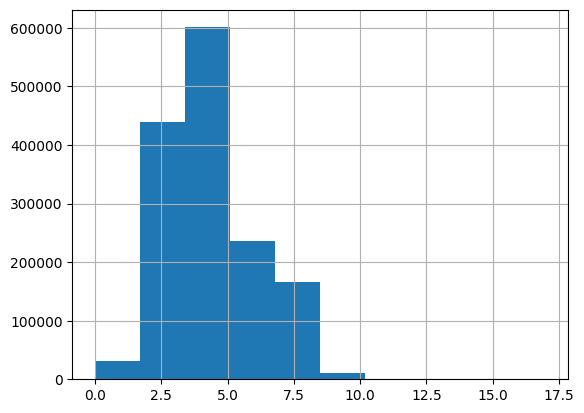

In [9]:
train.seq_name.apply(lambda x: len(x)).hist()

In [12]:
train.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,seq_item_description,seq_name
0,0,MLB Cincinnati Reds T Shirt Size XL,3,829,5265,10.0,1,No description yet,"[12, 68, 79]","[3852, 8823, 6896, 208, 84, 6, 155]"
1,1,Razer BlackWidow Chroma Keyboard,3,86,3889,52.0,0,This keyboard is in great condition and works ...,"[29, 2627, 10, 7, 39, 17, 1, 207, 51, 19, 1113...","[10760, 25565, 16369, 2627]"
2,2,AVA-VIV Blouse,1,1277,4588,10.0,1,Adorable top with a hint of lace and a key hol...,"[604, 60, 9, 4, 5347, 11, 192, 1, 4, 886, 1290...","[7634, 10563, 666]"
3,3,Leather Horse Statues,1,503,5265,35.0,1,New with tags. Leather horses. Retail for [rm]...,"[5, 9, 61, 178, 6528, 230, 3, 21, 166, 1085, 2...","[178, 2610, 14248]"
4,4,24K GOLD plated rose,1,1204,5265,44.0,0,Complete with certificate of authenticity,"[807, 9, 6888, 11, 1997]","[4884, 104, 1032, 280]"


<Axes: >

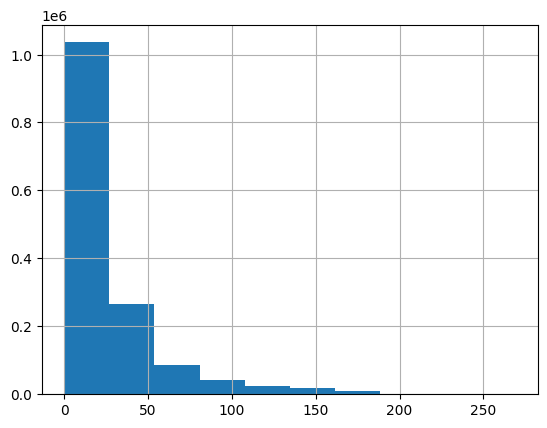

In [13]:
train.seq_item_description.apply(lambda x: len(x)).hist()

In [14]:
MAX_NAME_SEQ = 10
MAX_ITEM_DESC_SEQ = 75
MAX_TEXT = np.max([np.max(train.seq_name.max()),
                   np.max(test.seq_name.max()),
                   np.max(train.seq_item_description.max()),
                   np.max(test.seq_item_description.max())]) + 2
MAX_CATEGORY = np.max([train.category_name.max(), test.category_name.max()]) + 1
MAX_BRAND = np.max([train.brand_name.max(), test.brand_name.max()]) + 1
MAX_CONDITION = np.max([train.item_condition_id.max(), test.item_condition_id.max()]) + 1

array([[<Axes: title={'center': 'target'}>]], dtype=object)

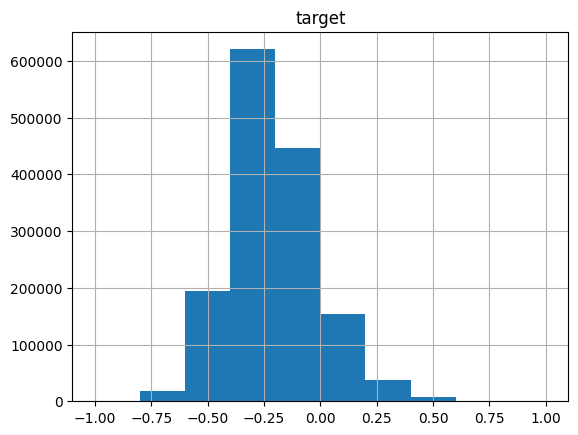

In [19]:
train['target'] = np.log(train.price + 1)
target_scaler = MinMaxScaler(feature_range=(-1, 1))
train['target'] = target_scaler.fit_transform(train['target'].to_numpy().reshape(-1, 1))
pd.DataFrame(train.target).hist()

In [16]:
dtrain, dvalid = train_test_split(train, random_state=123, train_size=0.99)
print(dtrain.shape)
print(dvalid.shape)

(1467709, 11)
(14826, 11)


In [20]:
from tf_keras.preprocessing.sequence import pad_sequences

def get_keras_data(dataset):
    X = {
        'name': pad_sequences(dataset.seq_name, maxlen=MAX_NAME_SEQ),
        'item_desc': pad_sequences(dataset.seq_item_description, maxlen=MAX_ITEM_DESC_SEQ),
        'brand_name': np.array(dataset.brand_name),
        'category_name': np.array(dataset.category_name),
        'item_condition': np.array(dataset.item_condition_id),
        'num_vars': np.array(dataset[['shipping']])
    }
    return X

X_train = get_keras_data(dtrain)
X_valid = get_keras_data(dvalid)
X_test = get_keras_data(test)

In [21]:
from tf_keras.layers import Input, Dropout, Dense, BatchNormalization, Activation, concatenate, GRU, Embedding, Flatten
from tf_keras.models import Model
from tf_keras.callbacks import ModelCheckpoint, Callback, EarlyStopping
from tf_keras import backend as K

def get_callbacks(filepath, patience=2):
    es = EarlyStopping('val_loss', patience=patience, mode='min')
    msave = ModelCheckpoint(filepath, save_best_only=True)
    return [es, msave]

def rmsle_cust(y_true, y_pred):
    first_log = K.log(K.clip(y_pred, K.epsilon(), None) + 1.)
    second_log = K.log(K.clip(y_true, K.epsilon(), None) + 1.)
    return K.sqrt(K.mean(K.square(first_log - second_log), axis=-1))

def get_model():
    dr_r = 0.1

    name = Input(shape=[X_train['name'].shape[1]], name='name')
    item_desc = Input(shape=[X_train['item_desc'].shape[1]], name='item_desc')
    brand_name = Input(shape=[1], name='brand_name')
    category_name = Input(shape=[1], name='category_name')
    item_condition = Input(shape=[1], name='item_condition')
    num_vars = Input(shape=[X_train['num_vars'].shape[1]], name='num_vars')

    emb_name = Embedding(MAX_TEXT, 50)(name)
    emb_item_desc = Embedding(MAX_TEXT, 50)(item_desc)
    emb_brand_name = Embedding(MAX_BRAND, 10)(brand_name)
    emb_category_name = Embedding(MAX_CATEGORY, 10)(category_name)
    emb_item_condition = Embedding(MAX_CONDITION, 5)(item_condition)

    rnn_layer1 = GRU(16)(emb_item_desc)
    rnn_layer2 = GRU(8)(emb_name)

    main_l = concatenate([
        Flatten()(emb_brand_name),
        Flatten()(emb_category_name),
        Flatten()(emb_item_condition),
        rnn_layer1,
        rnn_layer2,
        num_vars
    ])
    main_l = Dropout(dr_r)(Dense(128)(main_l))
    main_l = Dropout(dr_r)(Dense(64)(main_l))

    output = Dense(1, activation='linear')(main_l)

    model = Model([name, item_desc, brand_name, category_name, item_condition, num_vars], output)
    model.compile(loss='mse', optimizer='adam', metrics=['mae', rmsle_cust])

    return model

model = get_model()
model.summary()



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 brand_name (InputLayer)     [(None, 1)]                  0         []                            
                                                                                                  
 category_name (InputLayer)  [(None, 1)]                  0         []                            
                                                                                                  
 item_condition (InputLayer  [(None, 1)]                  0         []                            
 )                                                                                                
                                                                                                  
 item_desc (InputLayer)      [(None, 75)]                 0         []                      

In [24]:
BATCH_SIZE = 20000
epochs = 5

model = get_model()
model.fit(X_train, dtrain.target, epochs=epochs, batch_size=BATCH_SIZE, validation_data=(X_valid, dvalid.target), verbose=1)

Epoch 1/5


74/74 [==============================] - 270s 4s/step - loss: 1.8728 - mae: 1.0037 - rmsle_cust: 0.3101 - val_loss: 0.3205 - val_mae: 0.4302 - val_rmsle_cust: 0.1091
Epoch 2/5
74/74 [==============================] - 85s 1s/step - loss: 0.3193 - mae: 0.4317 - rmsle_cust: 0.1094 - val_loss: 0.2613 - val_mae: 0.3877 - val_rmsle_cust: 0.0986
Epoch 3/5
74/74 [==============================] - 81s 1s/step - loss: 0.2810 - mae: 0.4035 - rmsle_cust: 0.1024 - val_loss: 0.2468 - val_mae: 0.3751 - val_rmsle_cust: 0.0954
Epoch 4/5
74/74 [==============================] - 85s 1s/step - loss: 0.2610 - mae: 0.3881 - rmsle_cust: 0.0985 - val_loss: 0.2398 - val_mae: 0.3695 - val_rmsle_cust: 0.0941
Epoch 5/5
74/74 [==============================] - 90s 1s/step - loss: 0.2468 - mae: 0.3771 - rmsle_cust: 0.0958 - val_loss: 0.2362 - val_mae: 0.3669 - val_rmsle_cust: 0.0934


In [25]:
val_preds = model.predict(X_valid)
val_preds = target_scaler.inverse_transform(val_preds)
val_preds = np.exp(val_preds) + 1

y_true = np.array(dvalid.price.values)
y_pred = val_preds[:, 0]
v_rmsle = rmsle(y_true, y_pred)
print('  RMSLE error on dev test: ' + str(v_rmsle))

464/464 [==============================] - 6s 10ms/step
  RMSLE error on dev test: 12.233061760737817


In [26]:
preds = model.predict(X_test, batch_size=BATCH_SIZE)
preds = target_scaler.inverse_transform(preds)
preds = np.exp(preds) - 1

submission = test[['test_id']]
submission['price'] = preds

35/35 [==============================] - 16s 440ms/step


C:\Users\USER\AppData\Local\Temp\ipykernel_14488\882127984.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission['price'] = preds


<Axes: >

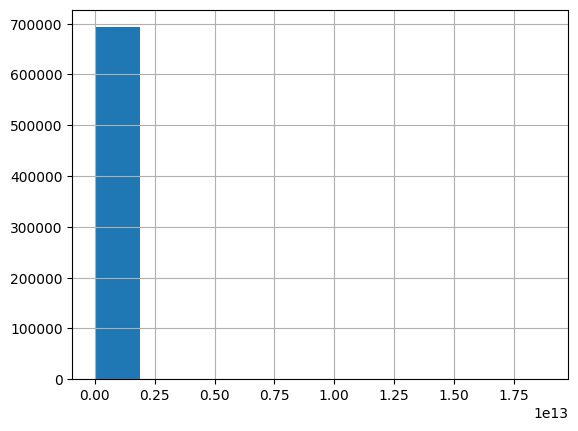

In [27]:
submission.to_csv('./myNNsubmission.csv', index=False)
submission.price.hist()

This was just an example how nn can solve this problems. Potential improvements of the kernel:

- Increase the embedding factos
- Descrease the batch size
- Add Batch Normalization
- Try LSTM, Bidirectional RNN, stack RNN
- Try with more dense layers or more rnn outputs
- etc. Or even try a new architecture!

Any comment will be welcome. Thanks!